# Run at First Time: nltk

In [ ]:
# import nltk
# nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/jiahao/nltk_data...


True

# model debug

In [ ]:
import numpy as np
from ruamel.yaml import YAML
yaml = YAML(typ='safe')

import torch
from models.model_search import Search

/home/jiahao/miniconda3/envs/cmp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = yaml.load(open('configs/tta_debug.yaml', 'r'))

model = Search(config=config)


/home/jiahao/miniconda3/envs/cmp/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


build_vision_encoder: load swin 224 x 224 ====>
missing_keys:  []
unexpected_keys:  ['head.weight', 'head.bias']
meta
meta
meta
meta
build_text_encoder: load bert ====>
missing_keys: ['bert.encoder.layer.10.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.10.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.10.crossattention.output.dense.bias', 'bert.encoder.layer.10.crossattention.output.dense.weight', 'bert.encoder.layer.10.crossattention.self.key.bias', 'bert.encoder.layer.10.crossattention.self.key.weight', 'bert.encoder.layer.10.crossattention.self.query.bias', 'bert.encoder.layer.10.crossattention.self.query.weight', 'bert.encoder.layer.10.crossattention.self.value.bias', 'bert.encoder.layer.10.crossattention.self.value.weight', 'bert.encoder.layer.11.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.11.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.11.crossattention.output.dense.bias', 'bert.encoder.layer.11.crossattention.output.dense

In [3]:
for n,m in model.named_parameters():
    print(n, m.device)

temp cpu
vision_encoder.patch_embed.proj.weight cpu
vision_encoder.patch_embed.proj.bias cpu
vision_encoder.patch_embed.norm.weight cpu
vision_encoder.patch_embed.norm.bias cpu
vision_encoder.layers.0.blocks.0.norm1.weight cpu
vision_encoder.layers.0.blocks.0.norm1.bias cpu
vision_encoder.layers.0.blocks.0.attn.relative_position_bias_table cpu
vision_encoder.layers.0.blocks.0.attn.qkv.weight cpu
vision_encoder.layers.0.blocks.0.attn.qkv.bias cpu
vision_encoder.layers.0.blocks.0.attn.proj.weight cpu
vision_encoder.layers.0.blocks.0.attn.proj.bias cpu
vision_encoder.layers.0.blocks.0.norm2.weight cpu
vision_encoder.layers.0.blocks.0.norm2.bias cpu
vision_encoder.layers.0.blocks.0.mlp.fc1.weight cpu
vision_encoder.layers.0.blocks.0.mlp.fc1.bias cpu
vision_encoder.layers.0.blocks.0.mlp.fc2.weight cpu
vision_encoder.layers.0.blocks.0.mlp.fc2.bias cpu
vision_encoder.layers.0.blocks.1.norm1.weight cpu
vision_encoder.layers.0.blocks.1.norm1.bias cpu
vision_encoder.layers.0.blocks.1.attn.relati

In [4]:
model.text_encoder.cls.predictions.decoder.bias

Parameter containing:
tensor(..., device='meta', size=(30522,), requires_grad=True)

In [5]:
ckpt_rpath0 = '/home/jiahao/task/CMP/checkpoint/jizheng/bert-base-uncased/pytorch_model.bin'
checkpoint0 = torch.load(ckpt_rpath0, map_location='cpu')

In [12]:
print(checkpoint0.keys())

odict_keys(['bert.embeddings.word_embeddings.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.LayerNorm.gamma', 'bert.embeddings.LayerNorm.beta', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.output.dense.weight', 'bert.encoder.layer.0.output.dense.bias', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.La

In [20]:
print("bert.encoder.layer.10.crossattention.output.dense.weight" in checkpoint0.keys(), "bert.embeddings.word_embeddings.weight" in checkpoint0.keys())

False True


In [15]:
# model.load_pretrained(args.checkpoint)
ckpt_rpath = 'checkpoint/cmp.pth'
checkpoint = torch.load(ckpt_rpath, map_location='cpu')
print('load checkpoint from %s' % ckpt_rpath)


load checkpoint from checkpoint/cmp.pth


In [16]:
print(checkpoint['model'].keys())


odict_keys(['temp', 'vision_encoder.patch_embed.proj.weight', 'vision_encoder.patch_embed.proj.bias', 'vision_encoder.patch_embed.norm.weight', 'vision_encoder.patch_embed.norm.bias', 'vision_encoder.layers.0.blocks.0.norm1.weight', 'vision_encoder.layers.0.blocks.0.norm1.bias', 'vision_encoder.layers.0.blocks.0.attn.relative_position_bias_table', 'vision_encoder.layers.0.blocks.0.attn.relative_position_index', 'vision_encoder.layers.0.blocks.0.attn.qkv.weight', 'vision_encoder.layers.0.blocks.0.attn.qkv.bias', 'vision_encoder.layers.0.blocks.0.attn.proj.weight', 'vision_encoder.layers.0.blocks.0.attn.proj.bias', 'vision_encoder.layers.0.blocks.0.norm2.weight', 'vision_encoder.layers.0.blocks.0.norm2.bias', 'vision_encoder.layers.0.blocks.0.mlp.fc1.weight', 'vision_encoder.layers.0.blocks.0.mlp.fc1.bias', 'vision_encoder.layers.0.blocks.0.mlp.fc2.weight', 'vision_encoder.layers.0.blocks.0.mlp.fc2.bias', 'vision_encoder.layers.0.blocks.1.attn_mask', 'vision_encoder.layers.0.blocks.1.nor

In [17]:
print(checkpoint['model']['text_encoder.cls.predictions.decoder.bias'].shape)
print(checkpoint['model']['text_encoder.cls.predictions.decoder.bias'])

torch.Size([30522])
tensor([-1.9392, -7.6318, -7.4379,  ..., -7.4573, -7.6915, -7.7719])


In [18]:

state_dict = checkpoint['model'] if 'model' in checkpoint.keys() else checkpoint
msg = model.load_state_dict(state_dict, strict=False)
print("missing_keys: ", [p for p in msg.missing_keys])
print("unexpected_keys: ", msg.unexpected_keys)


missing_keys:  []
unexpected_keys:  []


/home/jiahao/miniconda3/envs/cmp/lib/python3.10/site-packages/torch/nn/modules/module.py:2441: UserWarning: for text_encoder.cls.predictions.decoder.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(


In [ ]:
for n,m in model.named_parameters():
    print(n, m.device)

In [ ]:
model.text_encoder.cls.predictions.decoder.bias

In [ ]:
checkpoint['model']['text_encoder.cls.predictions.decoder.bias']

In [ ]:
model.text_encoder.cls.predictions.decoder.bias = checkpoint['model']['text_encoder.cls.predictions.decoder.bias']

In [ ]:
for n,m in model.named_parameters():
    print(n, m.device)

In [ ]:
model = model.to('cuda')


# Sample Selection ITC Score

In [48]:
sims_matrix_t2i = torch.from_numpy(np.load("/data/jiahao/PAB_TTA/debug_embeddings/sims_matrix_t2i.npy"))
q_pids = torch.from_numpy(np.load("/data/jiahao/PAB_TTA/debug_embeddings/q_pids.npy"))
g_pids = torch.from_numpy(np.load("/data/jiahao/PAB_TTA/debug_embeddings/g_pids.npy"))

In [49]:
def sample_selection_itc(sims_matrix_t2i, sims_matrix_i2t):
    # find_inter_top1_sample_selection
    ss_idxs_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):
        top1_sim_t2i, top1_idx_t2i = sims_t2i.topk(k=1, dim=0) # 获取t2i top1的相似度(top1_sim_t2i)和索引(top1_idx_t2i)
        top1_sim_i2t, top1_idx_i2t  = sims_matrix_i2t[top1_idx_t2i][0].topk(k=1, dim=0) # 获取top1_idx_t2i对应的i2t相似度和索引
        if top1_idx_i2t == i: # 只保留t2i和i2t互为top1的样本
            ss_idxs_list.append(i)
        # else:
        #     print(f"t2i & i2t do not have inter top1 sample: i2t_idx={i}, t2i_idx={top1_idx_t2i}, top1_sim_i2t={top1_sim_i2t}, top1_sim_t2i={top1_sim_t2i}")

    return ss_idxs_list

ss_idxs_list = sample_selection_itc(sims_matrix_t2i, sims_matrix_t2i.t())
ss_sims_matrix_t2i=sims_matrix_t2i[ss_idxs_list]
ss_q_pids=q_pids[ss_idxs_list]

In [50]:
from eval import mAP
print(mAP(sims_matrix_t2i, g_pids, q_pids))
print(mAP(ss_sims_matrix_t2i, g_pids, ss_q_pids))

/home/jiahao/task/CMP/eval.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  def mAP(scores_t2i, g_pids, q_pids, table=None):
/home/jiahao/task/CMP/eval.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  indices = torch.argsort(similarity, dim=1, descending=True)
/home/jiahao/task/CMP/eval.py:125: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  g_pids = torch.tensor(g_pids)


+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 69.414 | 95.197 | 97.776 | 81.233 | 81.233 |
+------+--------+--------+--------+--------+--------+
{'R1': np.float32(69.41355), 'R5': np.float32(95.197174), 'R10': np.float32(97.77553), 'mAP': array(81.2331, dtype=float32), 'mINP': array(81.2331, dtype=float32)}
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 86.953 | 98.727 | 99.602 | 92.588 | 92.588 |
+------+--------+--------+--------+--------+--------+
{'R1': np.float32(86.953064), 'R5': np.float32(98.72713), 'R10': np.float32(99.60223), 'mAP': array(92.587875, dtype=float32), 'mINP': array(92.587875, dtype=float32)}


# mAP逐行解释

In [ ]:
# print(mAP(sims_matrix_t2i, g_pids, q_pids))
scores_t2i = sims_matrix_t2i
similarity = torch.tensor(scores_t2i)
indices = torch.argsort(similarity, dim=1, descending=True)
g_pids = torch.tensor(g_pids)
q_pids = torch.tensor(q_pids)
print()
print('mAP start ')
pred_labels = g_pids[indices.cpu()]  # q * k
# 根据排序结果，获取每个查询对应的预测标签序列
# 关键操作：g_pids[indices]将图像ID按排序后的索引重新排列
# 结果：pred_labels是一个[q, k]的张量，每行表示该查询下候选图像的ID顺序
matches = pred_labels.eq(q_pids.view(-1, 1))  # q * k #找到label(q_pids)在pred_labels的位置并用T/F的matrix展示出来
# 核心比较：检查预测标签是否与查询ID匹配
# 技术细节：
# q_pids.view(-1, 1)将查询ID重塑为[q, 1]形状
# 通过广播机制与pred_labels([q, k])进行比较
# 结果：布尔张量matches，形状[q, k]，True表示匹配成功
# 示例：若q_pids[0]=5且pred_labels[0]=[3,5,1,2]，则matches[0]=[False,True,False,False]

all_cmc = matches[:, :10].cumsum(1)  # cumulative sum # top10做累加
# 仅考虑前10个候选结果（top-10）
# cumsum(1)沿候选维度计算累积和，表示在前n个结果中至少有一个匹配的比例
# 示例：若matches[0,:10]=[F,T,F,F,T,...]，则cumsum=[0,1,1,1,2,...]
all_cmc[all_cmc > 1] = 1
# 关键处理：将累积和大于1的值设为1
# 原因：CMC关注的是"是否找到匹配"，而非"找到几个匹配"
# 数学意义：将累积计数转换为二元指示（0=未找到，1=已找到）
# print(all_cmc.shape)
# all_cmc = all_cmc[ss_idxs_list]
# print(all_cmc.shape)
all_cmc = all_cmc.float().mean(0) * 100
# 计算所有查询的平均值：mean(0)得到每个rank位置的平均匹配率
# 乘以100转换为百分比形式
# 结果：all_cmc是一个长度为10的向量，表示Recall@1到Recall@10

num_rel = matches.sum(1)  # q
# 计算每个查询的相关项数量（即匹配的候选数量）
# 结果：长度为q的向量，表示每个查询有多少个正确匹配
tmp_cmc = matches.cumsum(1)  # q * k
# 计算整个候选集的累积匹配数（不截断前10） # 与all_cmc = matches[:, :10].cumsum(1)截断top10操作一致
# 用途：为后续计算AP和mINP做准备

inp = [tmp_cmc[i][match_row.nonzero()[-1]] / (match_row.nonzero()[-1] + 1.) for i, match_row in enumerate(matches)]
print(matches[0].shape)
print(matches[0].nonzero().shape)
print(matches[0].nonzero()[-1])
print(matches[0].nonzero())
print(inp)
mINP = torch.cat(inp).mean() * 100
print(torch.cat(inp).shape)
print(torch.cat(inp).mean())
# mINP计算逻辑：
# match_row.nonzero()[-1]：获取每个查询最后一个匹配项的位置索引
# tmp_cmc[i][...]：获取到该位置的累积匹配数（应等于匹配总数）
# 除以(索引 + 1)：得到最后一个匹配项的排名倒数
# 计算所有查询的平均值，乘以100转换为百分比
# 意义：mINP衡量的是第一个匹配项的倒数排名的平均值，值越高表示性能越好
# 优势：对早期检索结果更敏感，比mAP更能反映排序质量

tmp_cmc = [tmp_cmc[:, i] / (i + 1.0) for i in range(tmp_cmc.shape[1])]
# tmp_cmc[:, i] / (i + 1.0)：计算每个rank位置的Precision@k
# Precision@k = (前k个结果中匹配的数量) / k
print(torch.stack(tmp_cmc, 1).shape)
print(matches.shape)
tmp_cmc = torch.stack(tmp_cmc, 1) * matches
print(tmp_cmc.shape)
# 乘以matches：只保留匹配位置的Precision值
# 非匹配位置设为0，不影响AP计算
print(tmp_cmc.sum(1).shape)
print(num_rel.shape)
AP = tmp_cmc.sum(1) / num_rel  # q
print(AP)
mAP = AP.mean() * 100
# AP计算：
# tmp_cmc.sum(1)：对每个查询，将所有匹配位置的Precision值相加
# 除以num_rel：得到Average Precision（AP）
# AP = (所有匹配位置的Precision之和) / 相关项总数
# mAP计算：所有查询的AP平均值，乘以100转换为百分比
# 意义：mAP综合考虑了检索结果的排序质量和覆盖率

t2i_cmc, t2i_mAP, t2i_mINP, _ = all_cmc, mAP, mINP, indices
t2i_cmc, t2i_mAP, t2i_mINP = t2i_cmc.numpy(), t2i_mAP.numpy(), t2i_mINP.numpy()

eval_result = {'R1': t2i_cmc[0],
                'R5': t2i_cmc[4],
                'R10': t2i_cmc[9],
                'mAP': t2i_mAP,
                'mINP': t2i_mINP,
                }
print('mAP end ')
print()
print(eval_result)

/tmp/ipykernel_2624111/1625902720.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  similarity = torch.tensor(scores_t2i)
/tmp/ipykernel_2624111/1625902720.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  g_pids = torch.tensor(g_pids)
/tmp/ipykernel_2624111/1625902720.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_pids = torch.tensor(q_pids)



mAP start 
torch.Size([1978])
torch.Size([1, 1])
tensor([0])
tensor([[0]])
[tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([0.2000]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([0.1667]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.0667]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.1667]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), ten

# 调整softmax_temper试验数值分布

## 结论
- softmax虽然在数值上缩小了top1和top-1的差距，但是放大了倍数，使得分布更陡峭
- 但要注意i2t和t2i的temperature要保持一致，否则proba1+proba2就会偏向某一方的结果
- 因此，无论i2t和t2i是否保持一致都可以把这个参数作为一个可学习参数加入训练

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from torch.nn import functional as F

sim = np.array([0.5417, 0.4880, 0.3868, 0.3824, 0.3771, 0.3719, 0.3716, 0.3647, 0.3621,
        0.3529, 0.3427, 0.3423, 0.3402, 0.3383, 0.3379, 0.3352, 0.3318, 0.3301,
        0.3276, 0.3273, 0.3260, 0.3204, 0.3202, 0.3190, 0.3163, 0.3125, 0.3083,
        0.3074, 0.3053, 0.3024, 0.2993, 0.2956, 0.2901, 0.2895, 0.2873, 0.2833,
        0.2828, 0.2797, 0.2791, 0.2788, 0.2776, 0.2771, 0.2760, 0.2748, 0.2734,
        0.2713, 0.2711, 0.2669, 0.2661, 0.2629, 0.2609, 0.2584, 0.2575, 0.2573,
        0.2567, 0.2565, 0.2560, 0.2544, 0.2520, 0.2514, 0.2502, 0.2501, 0.2494,
        0.2480, 0.2479, 0.2473, 0.2455, 0.2444, 0.2441, 0.2400, 0.2399, 0.2398,
        0.2395, 0.2377, 0.2374, 0.2371, 0.2364, 0.2358, 0.2358, 0.2357, 0.2337,
        0.2332, 0.2330, 0.2327, 0.2326, 0.2281, 0.2268, 0.2267, 0.2259, 0.2257,
        0.2255, 0.2253, 0.2231, 0.2226, 0.2216, 0.2209, 0.2208, 0.2208, 0.2206,
        0.2206, 0.2181, 0.2180, 0.2160, 0.2156, 0.2156, 0.2136, 0.2133, 0.2128,
        0.2122, 0.2107, 0.2097, 0.2090, 0.2083, 0.2080, 0.2064, 0.2064, 0.2054,
        0.2053, 0.2049, 0.2046, 0.2045, 0.2042, 0.2040, 0.2035, 0.2031, 0.2031,
        0.2027, 0.2026])

/tmp/ipykernel_2624111/3055149423.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)).numpy())
/tmp/ipykernel_2624111/3055149423.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy())


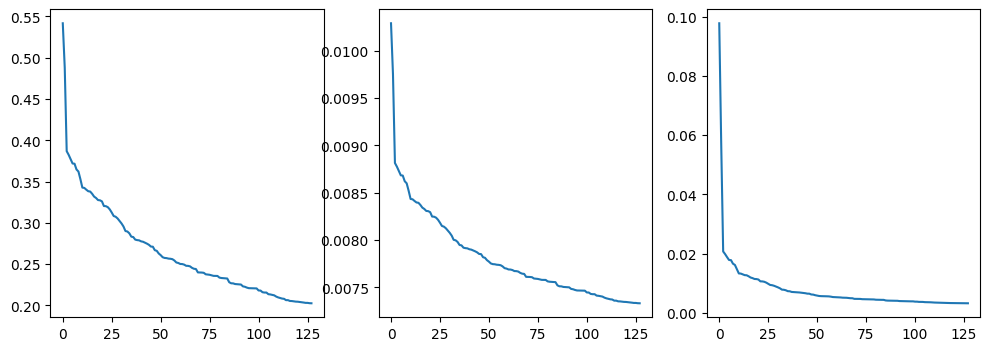

In [82]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(sim)
plt.subplot(1,3,2)
plt.plot(F.softmax(torch.from_numpy(sim)).numpy())
plt.subplot(1,3,3)
plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy())

/tmp/ipykernel_2624111/3406763281.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)).numpy()*50)
/tmp/ipykernel_2624111/3406763281.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy()*5)


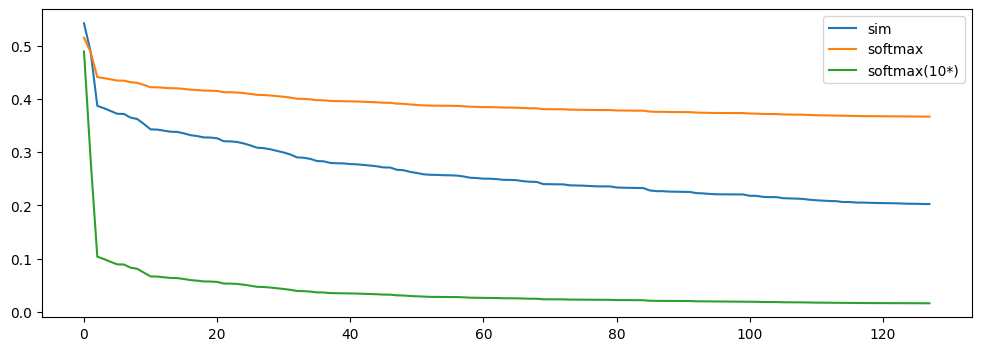

In [86]:
plt.figure(figsize=(12,4))

# plt.subplot(1,3,1)
plt.plot(sim)
# plt.subplot(1,3,2)
plt.plot(F.softmax(torch.from_numpy(sim)).numpy()*50)
# plt.subplot(1,3,3)
plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy()*5)
plt.legend(["sim","softmax","softmax(10*)"])

# Todo

In [100]:
assert 1==1, "aaaaa"